# **Transfer Learning với ResNet50 cho Vietnamese Sign Language**


## **I. Import thư viện và thiết lập tham số**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **II. Cài đặt các thông số cơ bản (Hyperparameters)**

In [ ]:
tfrecord_dir = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data/tfrecords'

In [ ]:
def get_dataset(path, batch_size=32):
    if not os.path.exists(path): return None

    # Cấu trúc feature
    features = {'image': tf.io.FixedLenFeature([], tf.string),
                'label': tf.io.FixedLenFeature([], tf.int64)}

    def parse(proto):
        parsed = tf.io.parse_single_example(proto, features)
        img = tf.image.resize(tf.io.decode_jpeg(parsed['image'], 3), [224, 224])
        return img, tf.cast(parsed['label'], tf.int32)

    return (tf.data.TFRecordDataset(path, "GZIP")
            .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Khởi tạo nhanh các dataset bằng Dictionary Comprehension
paths = {s: os.path.join(tfrecord_dir, f"{s}.tfrecord") for s in ['train', 'val', 'test']}
datasets = {s: get_dataset(p) for s, p in paths.items()}

# Kiểm tra thử tập test
if datasets['test']:
    for imgs, lbls in datasets['test'].take(1):
        print(f"Thành công! Image shape: {imgs.shape}, Label shape: {lbls.shape}")

Thành công! Image shape: (32, 224, 224, 3), Label shape: (32,)


In [ ]:
# Thông số mô hình
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25
SEED = 42

print(f"Cấu hình:")
print(f"- Kích thước ảnh: {IMG_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Số lớp: {NUM_CLASSES}")

Cấu hình:
- Kích thước ảnh: (224, 224)
- Batch size: 32
- Số lớp: 25


## **III. Tải dữ liệu đã được chia sẵn**

In [ ]:
print("Đang gán dữ liệu từ các tệp TFRecord đã đọc...")

train_ds = datasets['train']
val_ds = datasets['val']
test_ds = datasets['test']

print(f"\nTrạng thái dữ liệu:")
print(f"- Train dataset: {'Sẵn sàng' if train_ds else 'Lỗi'}")
print(f"- Val dataset: {'Sẵn sàng' if val_ds else 'Lỗi'}")
print(f"- Test dataset: {'Sẵn sàng' if test_ds else 'Lỗi'}")

Đang gán dữ liệu từ các tệp TFRecord đã đọc...

Trạng thái dữ liệu:
- Train dataset: Sẵn sàng
- Val dataset: Sẵn sàng
- Test dataset: Sẵn sàng


In [ ]:
def count_actual_batches(ds, name):
    if ds:
        count = 0
        for _ in ds:
            count += 1
        print(f"- {name} (Thực tế): {count} batches")
    else:
        print(f"- {name}: Không có dữ liệu")

print("Đang đếm số lượng batches thực tế (quá trình này có thể mất ít phút...):")
count_actual_batches(train_ds, "Train dataset")
count_actual_batches(val_ds, "Val dataset")
count_actual_batches(test_ds, "Test dataset")

Đang đếm số lượng batches thực tế (quá trình này có thể mất ít phút...):
- Train dataset (Thực tế): 625 batches
- Val dataset (Thực tế): 78 batches
- Test dataset (Thực tế): 79 batches


## **IV. Tiền xử lý và tăng cường dữ liệu (Data Augmentation)**

In [ ]:
# Hàm tiền xử lý cho ResNet50
def preprocess_for_resnet(image, label):
    image = preprocess_input(image)
    return image, label

# Hàm tăng cường dữ liệu
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

# Áp dụng augmentation cho tập train
train_ds_augmented = train_ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_augmented = train_ds_augmented.map(preprocess_for_resnet, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_augmented = train_ds_augmented.prefetch(tf.data.AUTOTUNE)

# Chỉ tiền xử lý cho tập val và test (không augmentation)
val_ds_processed = val_ds.map(preprocess_for_resnet, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_processed = val_ds_processed.prefetch(tf.data.AUTOTUNE)

test_ds_processed = test_ds.map(preprocess_for_resnet, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_processed = test_ds_processed.prefetch(tf.data.AUTOTUNE)

print("Đã áp dụng data augmentation và preprocessing.")

Đã áp dụng data augmentation và preprocessing.


## **V. Xây dựng mô hình với Transfer Learning**

In [ ]:
print("Đang khởi tạo mô hình ResNet50...")

# Tải mô hình ResNet50 đã được huấn luyện trên ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Đóng băng toàn bộ mạng gốc
base_model.trainable = False

# Gắn "Đầu" mới cho 25 lớp
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

print(f"\nTổng số layers: {len(model.layers)}")
print(f"Số layers trainable: {sum([1 for layer in model.layers if layer.trainable])}")
print(f"Số layers frozen: {sum([1 for layer in model.layers if not layer.trainable])}")

Đang khởi tạo mô hình ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Tổng số layers: 178
Số layers trainable: 3
Số layers frozen: 175


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 47,224,756 (180.15 MB)

 Trainable params: 23,585,817 (89.97 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 23,585,819 (89.97 MB)

## **VI. Giai đoạn 1: Warmup - Huấn luyện lớp đầu**

In [ ]:
print("\n=== BẮT ĐẦU GIAI ĐOẠN 1: WARMUP ===")

# Hàm định nghĩa Learning Rate Warmup
def lr_warmup_scheduler(epoch, lr):
    warmup_epochs = 3
    target_lr = 1e-3
    if epoch < warmup_epochs:
        new_lr = target_lr * ((epoch + 1) / warmup_epochs)
        print(f"\n[Warmup] Epoch {epoch + 1}: Tăng LR lên {new_lr:.6f}")
        return new_lr
    else:
        print(f"\n[Warmup] Epoch {epoch + 1}: Giữ ổn định LR ở mức {target_lr:.6f}")
        return target_lr

warmup_callback = LearningRateScheduler(lr_warmup_scheduler)

# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện 5 epoch chỉ với lớp đầu
history_stage1 = model.fit(
    train_ds_augmented,
    validation_data=val_ds_processed,
    epochs=5,
    callbacks=[warmup_callback]
)

print("\nHoàn tất Giai đoạn 1!")


=== BẮT ĐẦU GIAI ĐOẠN 1: WARMUP ===

[Warmup] Epoch 1: Tăng LR lên 0.000333
Epoch 1/5
    625/Unknown 87s 116ms/step - accuracy: 0.4681 - loss: 1.9489

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 136ms/step - accuracy: 0.6772 - loss: 1.1553 - val_accuracy: 0.9195 - val_loss: 0.3608 - learning_rate: 3.3333e-04

[Warmup] Epoch 2: Tăng LR lên 0.000667
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.9183 - loss: 0.3101 - val_accuracy: 0.9503 - val_loss: 0.1730 - learning_rate: 6.6667e-04

[Warmup] Epoch 3: Tăng LR lên 0.001000
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.9539 - loss: 0.1742 - val_accuracy: 0.9651 - val_loss: 0.1214 - learning_rate: 0.0010

[Warmup] Epoch 4: Giữ ổn định LR ở mức 0.001000
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 126ms/step - accuracy: 0.9660 - loss: 0.1201 - val_accuracy: 0.9784 - val_loss: 0.0833 - learning_rate: 0.0010

[Warmup] Epoch 5: Giữ ổn định LR ở mức 0.001000
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 126ms/step - accuracy: 0.9734 - loss: 0.0945 - val_accuracy: 0.9760 - val_loss: 0.0805 - learning_rate: 0.0010

Hoàn tất Giai đoạn 1!


## **VII. Giai đoạn 2: Fine-tuning - Tinh chỉnh toàn bộ mô hình**

In [ ]:
print("\n=== BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING ===")

# Rã đông mô hình
base_model.trainable = True

print(f"Số layers trainable sau khi unfreeze: {sum([1 for layer in model.layers if layer.trainable])}")

# Biên dịch lại mô hình với SGD, tốc độ học rất nhỏ
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Các Callback bảo vệ mô hình
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Huấn luyện sâu
history_stage2 = model.fit(
    train_ds_augmented,
    validation_data=val_ds_processed,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

print("\nHoàn tất Giai đoạn 2!")


=== BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING ===
Số layers trainable sau khi unfreeze: 178
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 343ms/step - accuracy: 0.8451 - loss: 0.4937 - val_accuracy: 0.9491 - val_loss: 0.1837 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 260s 415ms/step - accuracy: 0.9161 - loss: 0.2716 - val_accuracy: 0.9651 - val_loss: 0.1272 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 210s 335ms/step - accuracy: 0.9369 - loss: 0.2010 - val_accuracy: 0.9720 - val_loss: 0.1001 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 210s 335ms/step - accuracy: 0.9511 - loss: 0.1639 - val_accuracy: 0.9776 - val_loss: 0.0850 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 210s 336ms/step - accuracy: 0.9579 - loss: 0.1360 - val_accuracy: 0.9784 - val_loss: 0.0752 - learning_rate: 1.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 209s 333ms/step - accuracy: 0.9644 - loss: 0.1203 - val_accuracy: 0.9796 - v

## **VIII. Đánh giá mô hình trên tập Test**

In [ ]:
print("\nĐang đánh giá mô hình trên tập Test...")

test_loss, test_accuracy = model.evaluate(test_ds_processed)

print(f"\n=== KẾT QUẢ TRÊN TẬP TEST ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Đang đánh giá mô hình trên tập Test...
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.9896 - loss: 0.0402

=== KẾT QUẢ TRÊN TẬP TEST ===
Test Loss: 0.0402
Test Accuracy: 0.9896 (98.96%)


## **IX. Vẽ biểu đồ quá trình huấn luyện**

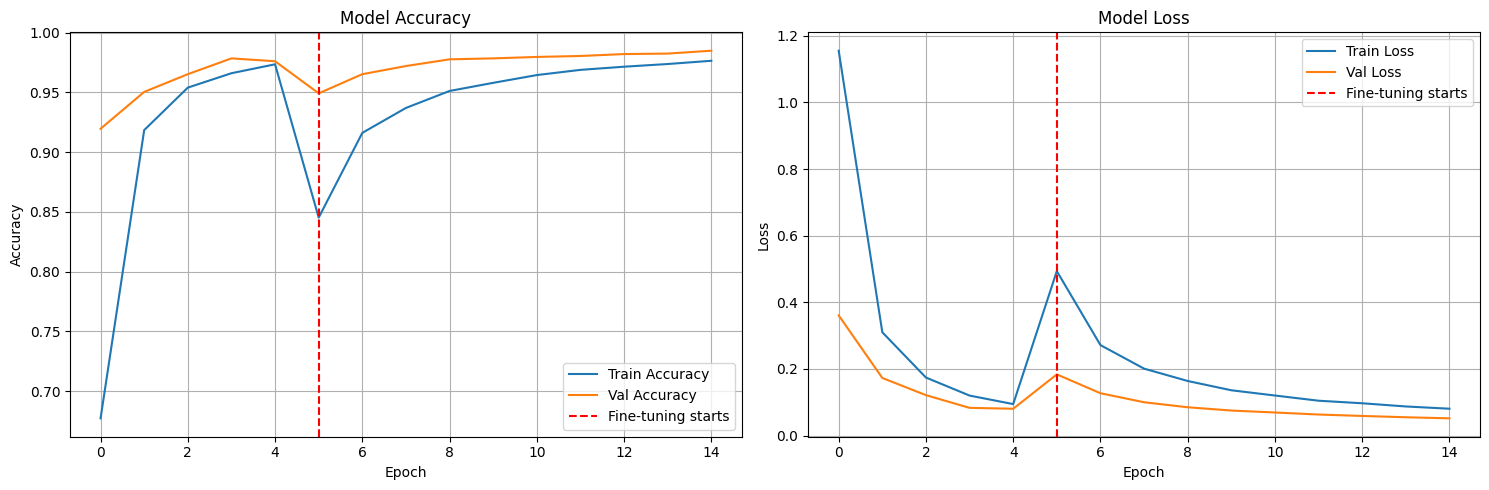

In [ ]:
# Kết hợp lịch sử từ cả 2 giai đoạn
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    return combined

full_history = combine_histories(history_stage1, history_stage2)

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(full_history['accuracy'], label='Train Accuracy')
axes[0].plot(full_history['val_accuracy'], label='Val Accuracy')
axes[0].axvline(x=5, color='red', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(full_history['loss'], label='Train Loss')
axes[1].plot(full_history['val_loss'], label='Val Loss')
axes[1].axvline(x=5, color='red', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **X. Lưu mô hình**

In [ ]:
# Lưu mô hình
model_save_path = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/models/resnet50_vsl.keras'
model.save(model_save_path)

print(f"\nMô hình đã được lưu tại: {model_save_path}")
print("Hoàn tất!")


Mô hình đã được lưu tại: /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/models/resnet50_vsl.keras
Hoàn tất!


## **XI. Kiểm tra dự đoán trên một số mẫu**

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


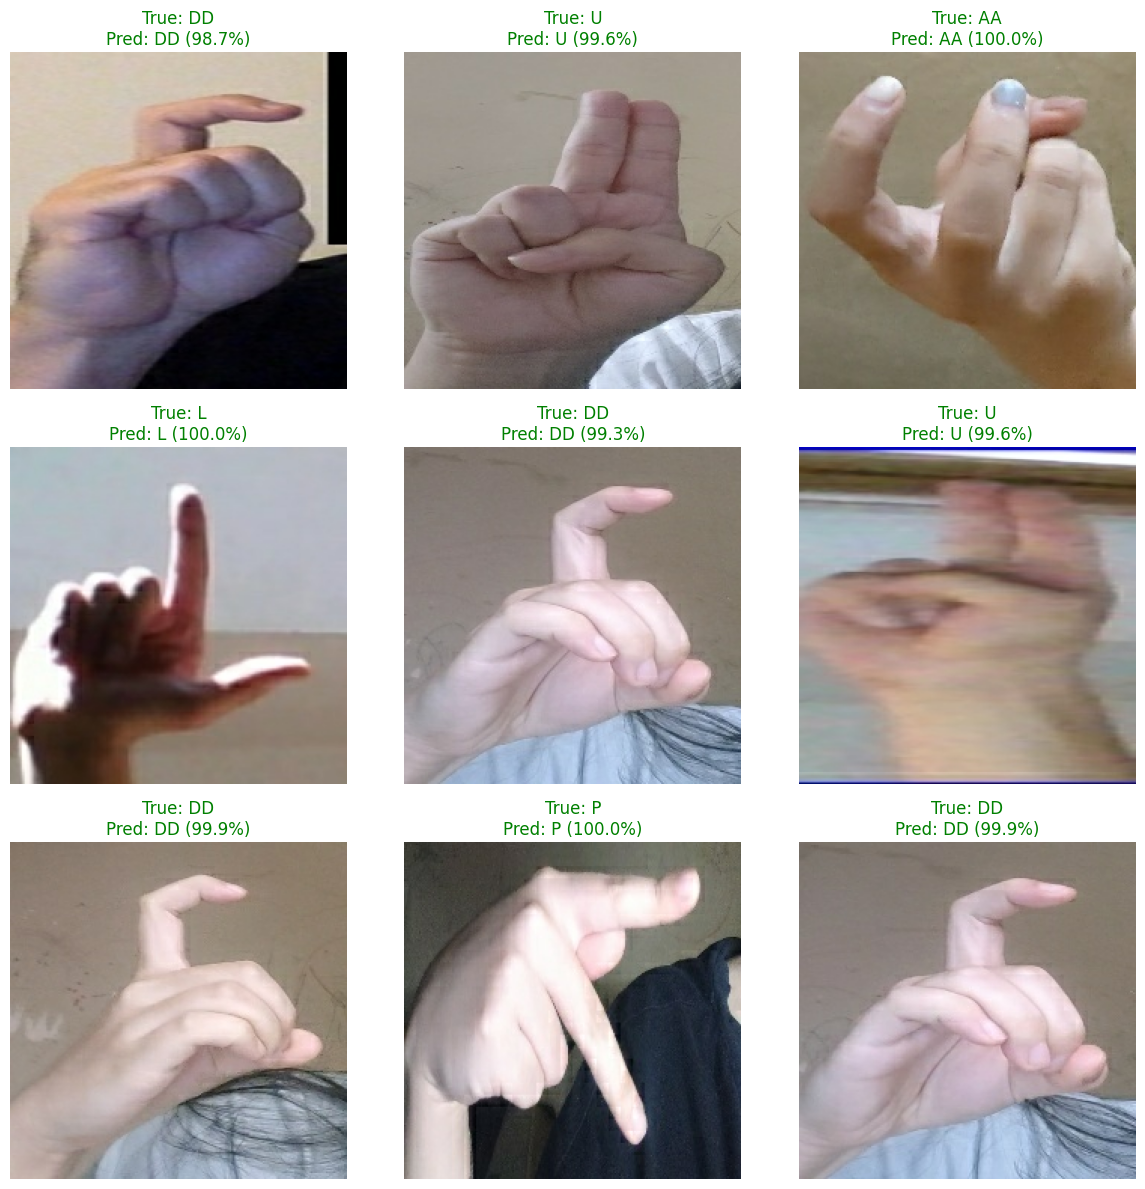

In [ ]:
# Lấy tên các lớp
class_names = ['A', 'AA', 'B', 'C', 'D', 'DD', 'E', 'G', 'H', 'I', 'K', 'L', 'M',
               'N', 'O', 'OOO', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']

# Lấy một batch từ tập test
for images, labels in test_ds.take(1):
    # Tiền xử lý ảnh
    processed_images = preprocess_input(images.numpy())

    # Dự đoán
    predictions = model.predict(processed_images)
    predicted_classes = np.argmax(predictions, axis=1)

    # Hiển thị 9 ảnh đầu tiên
    plt.figure(figsize=(12, 12))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[predicted_classes[i]]
        confidence = predictions[i][predicted_classes[i]] * 100

        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break